# 1. install requirement packages

In [1]:
%%capture
import subprocess

# Tải Meilisearch binary (Linux x86_64)
!wget https://github.com/meilisearch/meilisearch/releases/latest/download/meilisearch-linux-amd64 -O meilisearch
!chmod +x meilisearch
!pip install meilisearch
!pip install tqdm

!pip install faiss-gpu-cu12 
!pip install open-clip-torch transformers pillow numpy -q
!pip install fastapi uvicorn pyngrok nest_asyncio python-multipart
!pip install rapidfuzz

# 2. Meilisearch Class(OCR)

In [2]:
import json
import os
import threading
from typing import List, Dict, Any, Optional
from pathlib import Path
import logging
import meilisearch
from rapidfuzz import fuzz
import time
def remove_vietnamese_accents(text: str) -> str:
    """
    Remove Vietnamese diacritics/accents to match processed dataset format
    """
    import unicodedata
    
    # Vietnamese accent mapping
    vietnamese_map = {
        'à': 'a', 'á': 'a', 'ả': 'a', 'ã': 'a', 'ạ': 'a',
        'ă': 'a', 'ằ': 'a', 'ắ': 'a', 'ẳ': 'a', 'ẵ': 'a', 'ặ': 'a',
        'â': 'a', 'ầ': 'a', 'ấ': 'a', 'ẩ': 'a', 'ẫ': 'a', 'ậ': 'a',
        'è': 'e', 'é': 'e', 'ẻ': 'e', 'ẽ': 'e', 'ẹ': 'e',
        'ê': 'e', 'ề': 'e', 'ế': 'e', 'ể': 'e', 'ễ': 'e', 'ệ': 'e',
        'ì': 'i', 'í': 'i', 'ỉ': 'i', 'ĩ': 'i', 'ị': 'i',
        'ò': 'o', 'ó': 'o', 'ỏ': 'o', 'õ': 'o', 'ọ': 'o',
        'ô': 'o', 'ồ': 'o', 'ố': 'o', 'ổ': 'o', 'ỗ': 'o', 'ộ': 'o',
        'ơ': 'o', 'ờ': 'o', 'ớ': 'o', 'ở': 'o', 'ỡ': 'o', 'ợ': 'o',
        'ù': 'u', 'ú': 'u', 'ủ': 'u', 'ũ': 'u', 'ụ': 'u',
        'ư': 'u', 'ừ': 'u', 'ứ': 'u', 'ử': 'u', 'ữ': 'u', 'ự': 'u',
        'ỳ': 'y', 'ý': 'y', 'ỷ': 'y', 'ỹ': 'y', 'ỵ': 'y',
        'đ': 'd',
        # Uppercase versions
        'À': 'A', 'Á': 'A', 'Ả': 'A', 'Ã': 'A', 'Ạ': 'A',
        'Ă': 'A', 'Ằ': 'A', 'Ắ': 'A', 'Ẳ': 'A', 'Ẵ': 'A', 'Ặ': 'A',
        'Â': 'A', 'Ầ': 'A', 'Ấ': 'A', 'Ẩ': 'A', 'Ẫ': 'A', 'Ậ': 'A',
        'È': 'E', 'É': 'E', 'Ẻ': 'E', 'Ẽ': 'E', 'Ẹ': 'E',
        'Ê': 'E', 'Ề': 'E', 'Ế': 'E', 'Ể': 'E', 'Ễ': 'E', 'Ệ': 'E',
        'Ì': 'I', 'Í': 'I', 'Ỉ': 'I', 'Ĩ': 'I', 'Ị': 'I',
        'Ò': 'O', 'Ó': 'O', 'Ỏ': 'O', 'Õ': 'O', 'Ọ': 'O',
        'Ô': 'O', 'Ồ': 'O', 'Ố': 'O', 'Ổ': 'O', 'Ỗ': 'O', 'Ộ': 'O',
        'Ơ': 'O', 'Ờ': 'O', 'Ớ': 'O', 'Ở': 'O', 'Ỡ': 'O', 'Ợ': 'O',
        'Ù': 'U', 'Ú': 'U', 'Ủ': 'U', 'Ũ': 'U', 'Ụ': 'U',
        'Ư': 'U', 'Ừ': 'U', 'Ứ': 'U', 'Ử': 'U', 'Ữ': 'U', 'Ự': 'U',
        'Ỳ': 'Y', 'Ý': 'Y', 'Ỷ': 'Y', 'Ỹ': 'Y', 'Ỵ': 'Y',
        'Đ': 'D'
    }
    
    # Apply mapping
    result = ""
    for char in text:
        if char in vietnamese_map:
            result += vietnamese_map[char]
        else:
            result += char
    
    return result

class SingletonMeta(type):
    """
    Metaclass để implement Singleton pattern
    Thread-safe singleton implementation
    """
    _instances = {}
    _lock: threading.Lock = threading.Lock()

    def __call__(cls, *args, **kwargs):
        """
        Thread-safe singleton instance creation
        """
        with cls._lock:
            if cls not in cls._instances:
                instance = super().__call__(*args, **kwargs)
                cls._instances[cls] = instance
        return cls._instances[cls]
    
    @classmethod
    def reset_instance(mcs, cls):
        """
        Reset singleton instance (useful for testing or config reload)
        """
        with mcs._lock:
            if cls in mcs._instances:
                del mcs._instances[cls]


class MeiliSearchService(metaclass=SingletonMeta):
    """
    Service để search OCR text bằng Meilisearch.
    Meilisearch có tốc độ search cực nhanh và setup đơn giản.
    Tự động typo tolerance và ranking algorithm tốt.
    """
    
    def __init__(self, host: str = None, port: int = None, api_key: str = None):
        # Chỉ khởi tạo nếu chưa được khởi tạo (singleton check)
        if hasattr(self, '_initialized'):
            return
        
        if meilisearch is None:
            raise ImportError("Meilisearch not installed. Run: pip install meilisearch")
        
        if host is None:
            host = MEILISEARCH_HOST
        if port is None:
            port = MEILISEARCH_PORT
        if api_key is None:
            api_key = MEILISEARCH_API_KEY
            
        self.host = host
        self.port = port
        self.api_key = api_key
        self.url = f"http://{host}:{port}"
        
        # Tạo sync client
        self.client = meilisearch.Client(self.url, api_key)
        
        # Cấu hình datasets
        self.datasets = LIST_DATASET
        self.index_names = [index_name for _, index_name in self.datasets]
        
        self._initialized = True
    
    @classmethod
    def get_instance(cls, host: str = None, port: int = None, api_key: str = None):
        """
        Get singleton instance (alternative way to access)
        """
        return cls(host, port, api_key)
    
    def create_indices(self):
        """
        Tạo indices với cấu hình tối ưu cho OCR search
        """
        try:
            for index_name in self.index_names:
                print(f"Creating/updating index: {index_name}")
                
                # Try to get existing index first
                index = None
                try:
                    index = self.client.get_index(index_name)
                    print(f"Index {index_name} already exists")
                except Exception:
                    # Index doesn't exist, create it
                    try:
                        task = self.client.create_index(index_name, {'primaryKey': 'id'})
                        print(f"Created index {index_name}, task: {task.task_uid if hasattr(task, 'task_uid') else 'N/A'}")                        
                        # Wait a bit for index to be ready
                        import time
                        time.sleep(1)
                        
                        # Now get the created index
                        index = self.client.get_index(index_name)
                    except Exception as create_e:
                        print(f"Failed to create index {index_name}: {create_e}")
                        continue
                
                # Configure search settings if we have the index
                if index:
                    try:
                        settings = {
                            'searchableAttributes': ['text'],
                            'displayedAttributes': ['video_name', 'frame_index', 'text'],
                            'filterableAttributes': ['video_name', 'frame_index'],
                            'sortableAttributes': [],
                            'rankingRules': [
                                'words',
                                'typo',
                                'proximity',
                                'attribute',
                                'sort',
                                'exactness'
                            ],
                            'pagination': {
                                'maxTotalHits': 5000  
                            },
                            'stopWords': [],
                            'synonyms': {},
                            'distinctAttribute': None,
                            'typoTolerance': {
                                'enabled': True,
                                'minWordSizeForTypos': {
                                    'oneTypo': 2,
                                    'twoTypos': 3
                                }
                            }
                        }
                        
                        task = index.update_settings(settings)
                        print(f"Index {index_name} settings updated, task: {task.task_uid if hasattr(task, 'task_uid') else 'N/A'}")
                    except Exception as settings_e:
                        print(f"Failed to update settings for {index_name}: {settings_e}")
                
                print(f"Index {index_name} ready")
        except Exception as e:
            print(f"Error in create_indices: {e}")
            raise
    
    def index_ocr_data(self, json_file_path: str, index_name: str):
        """
        Index dữ liệu OCR từ file JSON vào Meilisearch.
        Chỉ index trường text, không index fps.
        
        Args:
            json_file_path: Đường dẫn đến file JSON
            index_name: Tên index để lưu dữ liệu
        """

        if index_name not in self.index_names:
            raise ValueError(f"Index name '{index_name}' not found in configured datasets")
            
        with open(json_file_path, 'r', encoding='utf-8') as f:
            data = json.load(f)
        
        video_name = Path(json_file_path).stem
        
        # Chuẩn bị documents cho Meilisearch
        documents = []
        for frame_index, frame_data in data.items():
            if isinstance(frame_data, dict) and 'text' in frame_data:
                text = frame_data['text']
                if text and text.strip():  # Chỉ index nếu text không rỗng
                    doc = {
                        "id": f"{index_name}_{video_name}_{frame_index}",
                        "video_name": video_name,
                        "frame_index": int(frame_index),
                        "text": text.strip(),
                        "dataset_type": index_name
                    }
                    documents.append(doc)
        
        # Add documents to Meilisearch
        if documents:
            try:
                index = self.client.get_index(index_name)
                task = index.add_documents(documents)
            except Exception as e:
                print(f"Error indexing {video_name} in {index_name}: {e}")
                raise

    def index_all_dataset(self):
        try:
            import time
            from tqdm import tqdm

            total_start = time.time()
            overall_success = 0
            overall_failed = 0
            
            BATCH_FILE_COUNT = 100 

            for data_path, index_name in self.datasets:
                if not os.path.exists(data_path):
                    print(f"Bỏ qua {index_name}: Thư mục {data_path} không tồn tại")
                    continue

                print(f"\nBắt đầu index {index_name}...")
                start_time = time.time()
                successful_files = 0
                failed_files = 0

                json_files = list(Path(data_path).rglob('*.json'))
                if not json_files:
                    print(f"Không tìm thấy file JSON nào trong {data_path}")
                    continue

                try:
                    index = self.client.get_index(index_name)
                except Exception as e:
                    print(f"  ✗ Không thể lấy index {index_name}. Bỏ qua bộ dữ liệu này. Lỗi: {e}")
                    continue
                
                document_batch = []

                for i, json_file in enumerate(tqdm(json_files, desc=f"Đang xử lý {index_name}", unit="file")):
                    try:
                        with open(json_file, 'r', encoding='utf-8') as f:
                            data = json.load(f)
                        
                        video_name = Path(json_file).stem
                        
                        for frame_index, frame_data in data.items():
                            if isinstance(frame_data, dict) and 'text' in frame_data:
                                text = frame_data['text']
                                if text and text.strip(): # Chỉ index nếu có text
                                    doc = {
                                        "id": f"{index_name}_{video_name}_{frame_index}",
                                        "video_name": video_name,
                                        "frame_index": int(frame_index),
                                        "text": text.strip(),
                                        "dataset_type": index_name
                                    }
                                    document_batch.append(doc)
                        successful_files += 1

                    except Exception as e:
                        # Ghi lại lỗi của từng file mà không làm dừng toàn bộ quá trình
                        tqdm.write(f"  ✗ Lỗi khi đọc hoặc xử lý file {json_file}: {e}")
                        failed_files += 1

                    # Điều kiện để gửi batch đi:
                    # 1. Đã xử lý đủ số file trong một batch (BATCH_FILE_COUNT)
                    # 2. Hoặc đã xử lý đến file cuối cùng của danh sách
                    if (i + 1) % BATCH_FILE_COUNT == 0 or (i + 1) == len(json_files):
                        if document_batch: # Chỉ gửi nếu batch không rỗng
                            try:
                                # Gửi toàn bộ batch đã gom được đến Meilisearch trong 1 lần gọi
                                task = index.add_documents(document_batch)
                                document_batch = [] # Reset lại batch để chuẩn bị cho lô tiếp theo
                            except Exception as e:
                                tqdm.write(f"  ✗ Lỗi khi index lô dữ liệu kết thúc bằng file {json_file}: {e}")
                
                elapsed = time.time() - start_time
                print(f"  ✓ Hoàn tất {index_name}: Thành công: {successful_files}, Thất bại: {failed_files} (trong {elapsed:.1f} giây)")
                
                overall_success += successful_files
                overall_failed += failed_files

            total_elapsed = time.time() - total_start
            print(f"\n✓ Đã index xong tất cả bộ dữ liệu: Thành công: {overall_success}, Thất bại: {overall_failed} (Tổng thời gian: {total_elapsed:.1f} giây)")

        except Exception as e:
            print(f"Một lỗi nghiêm trọng đã xảy ra trong quá trình index: {e}")

    
    def search_ocr(self, query: str, size: int = 1000) -> List[Dict[str, Any]]:
        """
        Fast OCR search với multi-search và re-ranking được tối ưu bằng fastfuzz.
        """
        normalized_query = remove_vietnamese_accents(query.strip()).lower()
        if not normalized_query:
            return []
    
        try:
            if not self.index_names:
                return []
                
            queries = [
                {
                    "indexUid": index_name,
                    "q": normalized_query,
                    "limit": size,
                    "attributesToRetrieve": ['*'],
                    'showRankingScore': True,
                    'matchingStrategy': 'last',
                }
                for index_name in self.index_names
            ]
            # 2. Gửi một yêu cầu multi-search duy nhất đến Meilisearch
            multi_search_response = self.client.multi_search(queries)
            # 3. Tập hợp kết quả từ tất cả các index vào một danh sách duy nhất
            search_result = []
            for response in multi_search_response['results']:
                # response['hits'] chứa danh sách các documents tìm thấy từ một index
                search_result.extend(response['hits'])
            
            # 4. Re-ranking hiệu suất cao với fastfuzz
            for result in search_result:
                text = result.get('text', '').strip()
                custom_score = self._calculate_match_quality_fastfuzz(text, normalized_query)
                final_score = (custom_score + result['_rankingScore']) / 2.0
                result['_rankingScore'] = final_score
    
            # Sắp xếp lại dựa trên điểm số cuối cùng
            search_result.sort(key=lambda x: x['_rankingScore'], reverse=True)
            
            # Loại bỏ trùng lặp và trả về kết quả
            deduplicated_results = self._deduplicate_results(search_result)
            return deduplicated_results[:size]
            
        except Exception as e:
            # Lỗi từ multi_search sẽ được bắt ở đây
            print(f"Multi-search error: {e}")
            return []

    def _calculate_match_quality_fastfuzz(self, text: str, query: str) -> float:
        """
        Tính toán chất lượng khớp nối bằng fastfuzz để đạt hiệu suất cao.
        Hàm này thay thế hoàn toàn cho hàm _calculate_match_quality cũ.

        Returns:
            Một điểm số trong khoảng [0.0, 1.0].
        """
        # Chuẩn hóa đầu vào
        text_norm = ' '.join(text.lower().split())
        
        if not query or not text_norm:
            return 0.0
            
        # 1. Kiểm tra khớp chính xác (trường hợp nhanh nhất và phổ biến)
        if query in text_norm:
            return 1.0
            
        # 2. Sử dụng fuzz.WRatio làm thước đo chính.
        # WRatio rất mạnh mẽ, nó tự động xử lý các trường hợp khác biệt về thứ tự từ,
        # khớp một phần, và các vấn đề phức tạp khác. Nó cho điểm từ 0-100.
        main_score = fuzz.WRatio(query, text_norm)
        
        # 3. Xử lý trường hợp đặc biệt: từ ghép không có khoảng trắng (ví dụ: "vet cay" -> "vetcay")
        # Trường hợp này WRatio có thể không xử lý tốt.
        concat_score = 0
        if ' ' in query: # Chỉ xử lý khi query có nhiều từ
            concatenated_query = "".join(query.split())
            # Tìm kiếm chuỗi ghép này bên trong văn bản đã loại bỏ khoảng trắng
            concat_score = fuzz.partial_ratio(concatenated_query, "".join(text_norm.split()))

        # 4. Lấy điểm cao nhất từ hai phương pháp
        final_score = max(main_score, concat_score)
        
        # 5. Chuẩn hóa điểm số về khoảng [0.0, 1.0]
        return final_score / 100.0
        
    def _deduplicate_results(self, results: List[Dict[str, Any]]) -> List[Dict[str, Any]]:
        """
        Remove duplicate results from multiple datasets.
        Keep the result with highest score for each video_name + frame_index combination.
        """
        if not results:
            return results
        
        # Group by unique video + frame combination
        unique_results = {}
        
        for result in results:
            video_name = result.get('video_name', '')
            frame_index = result.get('frame_index', 0)
            
            # Create unique key
            unique_key = f"{video_name}_{frame_index}"
            
            if unique_key not in unique_results:
                # First occurrence - add it
                unique_results[unique_key] = result
            else:
                # Duplicate found - keep higher score result
                current_score = result.get('_rankingScore', 0)
                existing_score = unique_results[unique_key].get('_rankingScore', 0)
                
                if current_score > existing_score:
                    # Replace with higher score result
                    unique_results[unique_key] = result
        
        # Convert back to list and sort by score
        deduplicated = list(unique_results.values())
        deduplicated.sort(key=lambda x: x.get('_rankingScore', 0), reverse=True)

        return deduplicated

# 3. Embedder Class

In [3]:
import numpy as np
import open_clip
import torch
from typing import List, Any

class CLIPEmbedder:
    """
    CLIP Embedder được tối ưu để chạy trên một GPU cụ thể.
    Đã loại bỏ logic DataParallel không cần thiết.
    """
    
    def __init__(self, device, model_name="ViT-H-14-quickgelu", pretrained="dfn5b", tokenizer_model=None):
        """
        Khởi tạo Embedder trên một device cụ thể (ví dụ: "cuda:0").
        """
        self.device = device
        self.model_name = model_name
        self.pretrained = pretrained
        # Nếu tokenizer_model không được cung cấp, mặc định sẽ dùng model_name
        self.tokenizer_model = tokenizer_model if tokenizer_model else model_name
        
        print(f"  -> Loading model '{self.model_name}' with pretrained '{self.pretrained}' onto device '{self.device}'...")
        self._load_model()
        
    def _load_model(self):
        """Load CLIP model, preprocess, và tokenizer lên device đã chỉ định."""
        try:
            self.model, _, self.preprocess = open_clip.create_model_and_transforms(
                self.model_name, 
                pretrained=self.pretrained,
                device=self.device
            )
            self.tokenizer = open_clip.get_tokenizer(self.tokenizer_model)
            self.model.eval()
        except Exception as e:
            print(f"❌ Failed to load model {self.model_name} on {self.device}. Error: {e}")
            raise e
    
    def encode_image(self, image):
        try:
            image_tensor = self.preprocess(image).unsqueeze(0).to(self.device)
            with torch.amp.autocast(self.device.type, enabled=self.device.type == 'cuda'):
                with torch.no_grad():
                    embedding = self.model.encode_image(image_tensor)
                    embedding_norm = torch.nn.functional.normalize(embedding, p=2, dim=-1)
            result = embedding_norm.cpu().numpy().flatten()
            del image_tensor, embedding, embedding_norm
            if self.device.type == 'cuda': 
                torch.cuda.empty_cache()
            return result
        except Exception as e:
            print(f"❌ Image encoding failed for model {self.model_name} on {self.device}: {e}")
            if self.device.type == 'cuda': torch.cuda.empty_cache()
            return None
    
    def encode_text(self, text):
        try:
            text_tokens = self.tokenizer([text]).to(self.device)
            with torch.amp.autocast(self.device.type, enabled=self.device.type == 'cuda'):
                with torch.no_grad():
                    embedding = self.model.encode_text(text_tokens)
                    embedding_norm = torch.nn.functional.normalize(embedding, p=2, dim=-1)
            result = embedding_norm.cpu().numpy().flatten()
            del text_tokens, embedding, embedding_norm
            if self.device.type == 'cuda': 
                torch.cuda.empty_cache()
            return result
        except Exception as e:
            print(f"❌ Text encoding failed for model {self.model_name} on {self.device}: {e}")
            if self.device.type == 'cuda': torch.cuda.empty_cache()
            return None

    def encode_batch(self, queries: List[Any]) -> np.ndarray:
        text_queries = [(i, q) for i, q in enumerate(queries) if isinstance(q, str)]
        image_queries = [(i, q) for i, q in enumerate(queries) if not isinstance(q, str)]
        
        final_embeddings = [None] * len(queries)
        
        if text_queries:
            indices, texts = zip(*text_queries)
            text_tokens = self.tokenizer(list(texts)).to(self.device)
            with torch.amp.autocast(self.device.type, enabled=self.device.type == 'cuda'):
                with torch.no_grad():
                    text_embeds = self.model.encode_text(text_tokens)
                    text_embeds = torch.nn.functional.normalize(text_embeds, p=2, dim=-1)
            for i, idx in enumerate(indices):
                final_embeddings[idx] = text_embeds[i].cpu().numpy()

        if image_queries:
            indices, images = zip(*image_queries)
            image_tensors = torch.stack([self.preprocess(img) for img in images]).to(self.device)
            with torch.amp.autocast(self.device.type, enabled=self.device.type == 'cuda'):
                with torch.no_grad():
                    image_embeds = self.model.encode_image(image_tensors)
                    image_embeds = torch.nn.functional.normalize(image_embeds, p=2, dim=-1)
            for i, idx in enumerate(indices):
                final_embeddings[idx] = image_embeds[i].cpu().numpy()

        return np.array(final_embeddings, dtype=np.float32)

# 4. FAISSSearchEngine(Multi-model)

In [4]:
import os
import faiss
from pathlib import Path
import numpy as np
import pickle
from typing import List, Dict, Tuple, Optional, Any
from tqdm.auto import tqdm
import torch
from collections import defaultdict
import concurrent.futures

class FAISSSearchEngine:
    """
    FAISS Search Engine quản lý nhiều chỉ mục và phân chia chúng lên các GPU khác nhau.
    """
    def __init__(self, list_faiss_configs: List[Dict[str, Any]]):
        self.configs = {cfg['model_name']: cfg for cfg in list_faiss_configs}
        self.embedders: Dict[str, Any] = {cfg['model_name']: cfg['embedder'] for cfg in list_faiss_configs}
        self.indexes: Dict[str, faiss.Index] = {}
        # Quản lý tài nguyên cho từng GPU riêng biệt
        self.gpu_resources_map: Dict[int, faiss.StandardGpuResources] = {}
        
        self.id_to_path_maps: Dict[str, Dict[int, str]] = {}
        self.path_to_id_maps: Dict[str, Dict[str, int]] = {}
        self.total_vectors: Dict[str, int] = {}
        self.embedding_dims: Dict[str, int] = {}

    def _get_gpu_resource(self, gpu_id: int) -> Optional[faiss.StandardGpuResources]:
        """Khởi tạo và trả về resource cho một GPU ID cụ thể."""
        if gpu_id not in self.gpu_resources_map:
            try:
                print(f"🚀 Initializing GPU resources for device cuda:{gpu_id}")
                self.gpu_resources_map[gpu_id] = faiss.StandardGpuResources()
            except Exception as e:
                print(f"⚠️ Failed to initialize resources for GPU {gpu_id}: {e}")
                self.gpu_resources_map[gpu_id] = None
        return self.gpu_resources_map[gpu_id]

    def _build_single_index(self, model_name: str):
        print(f"\n--- Building index for model: '{model_name}' ---")
        config = self.configs[model_name]
        # Đường dẫn tới file pickle chứa embeddings
        embedding_file_path = Path(config['embedding_path'])

        if not embedding_file_path.is_file() or embedding_file_path.suffix != '.pkl':
            print(f"❌ Embedding path for '{model_name}' is not a valid pickle file: {embedding_file_path}")
            return

        try:
            with open(embedding_file_path, 'rb') as f:
                data = pickle.load(f)
            embeddings_array = data['embeddings']
            paths = data['paths']
            num_vectors = data['length']
        except (FileNotFoundError, KeyError, Exception) as e:
            print(f"❌ Failed to load or parse embedding file for '{model_name}': {e}")
            return
        
        if len(embeddings_array) != num_vectors or len(paths) != num_vectors:
            print(f"❌ Data inconsistency in pickle file for '{model_name}': Mismatch in lengths.")
            return

        self.embedding_dims[model_name] = embeddings_array.shape[1]
        d = self.embedding_dims[model_name]
        
        # Tạo id-path và path-id maps
        self.id_to_path_maps[model_name] = {i: path for i, path in enumerate(paths)}
        self.path_to_id_maps[model_name] = {path: i for i, path in enumerate(paths)}

        self.total_vectors[model_name] = num_vectors
        
        index_type = config.get("index_type", "Flat")
        if index_type == "Flat":
            cpu_index = faiss.IndexFlatIP(d)
        elif index_type == "IVF":
            nlist = config.get("nlist", 1024)
            quantizer = faiss.IndexFlatIP(d)
            cpu_index = faiss.IndexIVFFlat(quantizer, d, nlist, faiss.METRIC_INNER_PRODUCT)
        else:
            raise ValueError(f"Unsupported index type '{index_type}' for model '{model_name}'")

        if index_type == "IVF":
            print(f"🔧 Training IVF index for '{model_name}'...")
            cpu_index.train(embeddings_array)

        print(f"📊 Adding {self.total_vectors[model_name]} embeddings to '{model_name}' index...")
        cpu_index.add(embeddings_array)
        
        embedder_device = self.embedders[model_name].device
        if config.get('use_gpu', False) and embedder_device.type == 'cuda':
            gpu_id = embedder_device.index
            res = self._get_gpu_resource(gpu_id)
            if res:
                try:
                    self.indexes[model_name] = faiss.index_cpu_to_gpu(res, gpu_id, cpu_index)
                    print(f"✅ Index for '{model_name}' is on GPU {gpu_id}.")
                except Exception as e:
                    print(f"⚠️ GPU transfer failed for '{model_name}', using CPU. Error: {e}")
                    self.indexes[model_name] = cpu_index
            else:
                self.indexes[model_name] = cpu_index
        else:
            self.indexes[model_name] = cpu_index
            print(f"✅ Index for '{model_name}' is on CPU.")
            
        if index_type == "IVF":
            self.indexes[model_name].nprobe = config.get("nprobe", 64)

    def build_all_indexes(self):
        for model_name in self.configs.keys():
            self._build_single_index(model_name)

    def save_all_indexes(self):
        for model_name, index in self.indexes.items():
            config = self.configs[model_name]
            output_path_str = config.get("output_index_path")
            if not output_path_str:
                print(f"⚠️ Skipping save for '{model_name}': 'output_index_path' not provided.")
                continue
            save_path = Path(output_path_str)
            save_path.mkdir(parents=True, exist_ok=True)
            print(f"--- Saving index for model: '{model_name}' to {save_path} ---")
            try:
                cpu_index = faiss.index_gpu_to_cpu(index) if 'gpu' in str(type(index)).lower() else index
                faiss.write_index(cpu_index, str(save_path / "faiss_index.bin"))
                metadata = {
                    'id_to_path': self.id_to_path_maps[model_name],
                    'path_to_id': self.path_to_id_maps[model_name],
                    'embedding_dim': self.embedding_dims[model_name],
                    'total_vectors': self.total_vectors[model_name]
                }
                with open(save_path / "metadata.pkl", 'wb') as f:
                    pickle.dump(metadata, f)
                print(f"✅ Saved '{model_name}' successfully.")
            except Exception as e:
                print(f"❌ Error saving index for '{model_name}': {e}")

    def load_all_indexes(self):
        for model_name, config in self.configs.items():
            load_path_str = config.get("input_index_path")
            if not load_path_str:
                print(f"⚠️ Skipping load for '{model_name}': 'input_index_path' not provided.")
                continue
            load_path = Path(load_path_str)
            print(f"\n--- Loading index for model: '{model_name}' from {load_path} ---")
            index_file, metadata_file = load_path / "faiss_index.bin", load_path / "metadata.pkl"
            if not index_file.exists() or not metadata_file.exists():
                print(f"⚠️ Skipping '{model_name}': missing index or metadata file in {load_path}.")
                continue
            try:
                cpu_index = faiss.read_index(str(index_file))
                with open(metadata_file, 'rb') as f: metadata = pickle.load(f)
                self.id_to_path_maps[model_name] = metadata['id_to_path']
                self.path_to_id_maps[model_name] = metadata['path_to_id']
                self.embedding_dims[model_name] = metadata['embedding_dim']
                self.total_vectors[model_name] = metadata['total_vectors']
                
                current_config = self.configs[model_name]
                embedder_device = self.embedders[model_name].device
                if current_config.get('use_gpu', False) and embedder_device.type == 'cuda':
                    gpu_id = embedder_device.index
                    res = self._get_gpu_resource(gpu_id)
                    if res:
                        self.indexes[model_name] = faiss.index_cpu_to_gpu(res, gpu_id, cpu_index)
                        print(f"✅ Index for '{model_name}' loaded on GPU {gpu_id}.")
                    else:
                        self.indexes[model_name] = cpu_index
                else:
                    self.indexes[model_name] = cpu_index
                    print(f"✅ Index for '{model_name}' loaded on CPU.")
                if current_config.get("index_type") == "IVF":
                    self.indexes[model_name].nprobe = current_config.get("nprobe", 64)
            except Exception as e:
                print(f"❌ Error loading index for '{model_name}': {e}")

    def _search_single_model(self, model_name: str, queries: List[Any], k: int) -> List[List[Tuple[str, float]]]:
        index = self.indexes.get(model_name)
        embedder = self.embedders.get(model_name)
        id_to_path = self.id_to_path_maps.get(model_name)
        if not all([index, embedder, id_to_path]):
            print(f"⚠️ Cannot search model '{model_name}': component is missing.")
            return [[] for _ in queries]
        query_array = embedder.encode_batch(queries)
        scores_batch, indices_batch = index.search(query_array, k)
        batch_results = []
        for scores, indices in zip(scores_batch, indices_batch):
            single_query_results = []
            for score, idx in zip(scores, indices):
                if idx != -1 and idx in id_to_path:
                    single_query_results.append((id_to_path[idx], float(score)))
            batch_results.append(single_query_results)
        return batch_results

    def search(
        self,
        queries: List[Any],
        models_to_search: List[Dict[str, Any]],
        k: int = 100
    ) -> List[List[Tuple[str, float]]]:
        raw_results_by_model: Dict[str, List[List[Tuple[str, float]]]] = {}
        model_configs = {m['model_name']: m for m in models_to_search}
        with concurrent.futures.ThreadPoolExecutor() as executor:
            future_to_model = {
                executor.submit(self._search_single_model, model_name, queries, k): model_name
                for model_name in model_configs.keys() if model_name in self.indexes
            }
            for future in concurrent.futures.as_completed(future_to_model):
                model_name = future_to_model[future]
                try:
                    raw_results_by_model[model_name] = future.result()
                except Exception as e:
                    print(f"❌ Search failed for model '{model_name}': {e}")
                    raw_results_by_model[model_name] = [[] for _ in queries]
        final_reranked_results = []
        num_queries = len(queries)
        for i in range(num_queries):
            fused_scores = defaultdict(float)
            for model_name, batch_results in raw_results_by_model.items():
                model_weight = model_configs[model_name].get('weight', 1.0)
                single_query_results = batch_results[i]
                for path, score in single_query_results:
                    fused_scores[path] += score * model_weight
            reranked_list = list(fused_scores.items())
            reranked_list.sort(key=lambda x: x[1], reverse=True)
            final_reranked_results.append(reranked_list[:k])
        return final_reranked_results
    
    def _load_embedding_worker(self, file_info: Tuple[int, str, Path]) -> Optional[Tuple[int, str, np.ndarray]]:
        # Phương thức này không còn được sử dụng khi tải từ tệp pickle duy nhất
        # nhưng vẫn giữ lại nếu cần dùng cho cơ chế cũ.
        unique_id, relative_path_npy, file_path = file_info
        try:
            embedding = np.load(file_path)
            jpg_path = relative_path_npy.replace('.npy', '.jpg')
            return (unique_id, jpg_path, embedding)
        except Exception: return None

    def cleanup_gpu_memory(self):
        if self.gpu_resources_map:
            del self.indexes
            del self.gpu_resources_map
            self.indexes = {}
            self.gpu_resources_map = {}
            if torch.cuda.is_available(): torch.cuda.empty_cache()
            print("🧹 GPU memory and indexes cleaned up.")

# 5. Search engine

In [5]:
from pathlib import Path
import numpy as np
import pickle
from typing import List, Dict, Tuple, Optional, Any
import torch
from collections import defaultdict
import json
from PIL import Image
import concurrent.futures
import time
import gc

class SearchEngine:
    """
    Search Engine được tối ưu hóa cho temporal search, tận dụng tối đa batch processing 
    và re-ranking đa mô hình.
    """
    def __init__(self, vector_engine: FAISSSearchEngine, ocr_engine: MeiliSearchService):
        """
        Khởi tạo Search Engine. Embedder giờ đây được quản lý bởi FAISSSearchEngine.
        """
        self.vector_engine = vector_engine
        self.ocr_engine = ocr_engine
        print("✅ Main SearchEngine (Optimized Multi-Model Version) initialized.")

    def _fuse_and_rerank_candidates(
        self,
        raw_text_results: List[Tuple[str, float]],
        raw_image_results: List[Tuple[str, float]],
        raw_ocr_results: List[Dict[str, Any]],
        weights: Dict[str, float]
    ) -> List[Tuple[str, float]]:
        """
        Hàm re-rank chuyên dụng.
        Kết hợp các kết quả thô và tính điểm tổng hợp.
        """
        all_scores = defaultdict(lambda: {'text': 0.0, 'image': 0.0, 'ocr': 0.0})
        for path, score in raw_text_results: all_scores[path]['text'] = score
        for path, score in raw_image_results: all_scores[path]['image'] = score
        for ocr_hit in raw_ocr_results:
            video_name = ocr_hit.get('video_name', '')
            frame_index = ocr_hit.get('frame_index', -1)
            ocr_score = ocr_hit.get('_rankingScore', 0.0) 
            if video_name and frame_index != -1:
                path = f"{video_name}/{frame_index}.jpg"
                all_scores[path]['ocr'] = ocr_score

        combined_results = []
        for path, scores in all_scores.items():
            fusion_score = (
                weights.get('text', 0.0) * scores['text'] +
                weights.get('image', 0.0) * scores['image'] +
                weights.get('ocr', 0.0) * scores['ocr']
            )
            if fusion_score > 0:
                combined_results.append((path, fusion_score))
        combined_results.sort(key=lambda x: x[1], reverse=True)
        return combined_results

    def hybrid_search(
        self,
        text_query: Optional[str] = None,
        image_query: Optional[Image.Image] = None,
        ocr_query: Optional[str] = None,
        k: int = 100,
        weights: Dict[str, float] = None,
        vector_models_config: Optional[List[Dict[str, Any]]] = None
    ) -> List[Tuple[str, float]]:
        """
        Thực hiện tìm kiếm hybrid cho một truy vấn đơn giản (một stage).
        """
        if weights is None: 
            weights = {'text': 0.45, 'ocr': 0.35, 'image': 0.20}
        if vector_models_config is None:
            # Lấy danh sách tất cả các tên model có sẵn trong engine
            available_model_names = list(self.vector_engine.configs.keys())
            num_models = len(available_model_names)
        
            if num_models > 0:
                # Chia đều trọng số 1.0 cho tất cả các model
                equal_weight = 1.0 / num_models
                
                # Tạo danh sách cấu hình mặc định
                vector_models_config = [
                    {'model_name': model_name, 'weight': equal_weight}
                    for model_name in available_model_names
                ]
            else:
                vector_models_config = []

        raw_results = {'text': [], 'image': [], 'ocr': []}
        
        vector_queries, vector_types = [], []
        if text_query: 
            vector_queries.append(text_query)
            vector_types.append('text')
        if image_query: 
            vector_queries.append(image_query)
            vector_types.append('image')

        with concurrent.futures.ThreadPoolExecutor() as executor:
            future_vector = None
            if vector_queries:
                future_vector = executor.submit(self.vector_engine.search, vector_queries, vector_models_config, k)
            
            future_ocr = None
            if ocr_query:
                future_ocr = executor.submit(self.ocr_engine.search_ocr, ocr_query, k)

            if future_vector:
                # `search` trả về một list kết quả cho mỗi truy vấn trong batch
                batch_vector_results = future_vector.result()
                for i, q_type in enumerate(vector_types):
                    raw_results[q_type] = batch_vector_results[i]

            if future_ocr:
                raw_results['ocr'] = future_ocr.result()

        combined_results = self._fuse_and_rerank_candidates(
            raw_text_results=raw_results['text'],
            raw_image_results=raw_results['image'],
            raw_ocr_results=raw_results['ocr'],
            weights=weights
        )
        return combined_results[:k]

    def temporal_search(
        self,
        queries: Optional[List[Dict[str, Any]]] = None,
        k: int = 10,
        max_chains_per_video: int = 5,
        initial_search_k: int = 1000,
        weights: Dict[str, float] = None,
        vector_models_config: Optional[List[Dict[str, Any]]] = None
    ) -> List[List[Tuple[str, float]]]:
        """
        Thực hiện tìm kiếm tuần tự theo thời gian với kiến trúc tối ưu hóa.
        """
        if not queries: 
            return []
        if weights is None: 
            weights = {'text': 0.55, 'ocr': 0.2, 'image': 0.25}
        if vector_models_config is None:
            # Lấy danh sách tất cả các tên model có sẵn trong engine
            available_model_names = list(self.vector_engine.configs.keys())
            num_models = len(available_model_names)
        
            if num_models > 0:
                # Chia đều trọng số 1.0 cho tất cả các model
                equal_weight = 1.0 / num_models
                
                # Tạo danh sách cấu hình mặc định
                vector_models_config = [
                    {'model_name': model_name, 'weight': equal_weight}
                    for model_name in available_model_names
                ]
            else:
                vector_models_config = []

        num_stages = len(queries)
        if num_stages <= 1: 
            stage_query = queries[0] if queries else {}
            # hybrid_search trả về một list, nhưng temporal yêu cầu list của list
            results = self.hybrid_search(
                text_query=stage_query.get('text'), 
                image_query=stage_query.get('image'),
                ocr_query=stage_query.get('ocr'), 
                k=k, 
                weights=weights,
                vector_models_config=vector_models_config
            )
            return results if results else []

        # --- BƯỚC 1: TẬP HỢP TẤT CẢ TRUY VẤN ---
        vector_queries_to_process, vector_batch_map, ocr_queries_to_process = [], [], []
        # Dùng một placeholder duy nhất cho các stage chỉ có OCR
        placeholder_query = "placeholder" 
        has_placeholder = False

        for stage_idx, stage_data in enumerate(queries):
            has_vector_query_in_stage = False
            if stage_data.get('text'):
                vector_queries_to_process.append(stage_data['text'])
                vector_batch_map.append({'stage_idx': stage_idx, 'type': 'text'})
                has_vector_query_in_stage = True
            if stage_data.get('image'):
                vector_queries_to_process.append(stage_data['image'])
                vector_batch_map.append({'stage_idx': stage_idx, 'type': 'image'})
                has_vector_query_in_stage = True
            if not has_vector_query_in_stage and stage_data.get('ocr'):
                if not has_placeholder:
                    vector_queries_to_process.append(placeholder_query)
                    has_placeholder = True
                vector_batch_map.append({'stage_idx': stage_idx, 'type': 'placeholder', 'query_ref': placeholder_query})
            if stage_data.get('ocr'):
                ocr_queries_to_process.append((stage_idx, stage_data['ocr']))
        
        # --- BƯỚC 2: THỰC THI SONG SONG ---
        batch_vector_results, ocr_results_by_stage = [], defaultdict(list)
        with concurrent.futures.ThreadPoolExecutor() as executor:
            future_vector = executor.submit(self.vector_engine.search, vector_queries_to_process, vector_models_config, initial_search_k)
            future_ocr = {executor.submit(self.ocr_engine.search_ocr, ocr_text, initial_search_k): stage_idx for stage_idx, ocr_text in ocr_queries_to_process}

            try: batch_vector_results = future_vector.result()
            except Exception as e: print(f"Lỗi batch vector search: {e}")
            for future in concurrent.futures.as_completed(future_ocr):
                try: ocr_results_by_stage[future_ocr[future]] = future.result()
                except Exception as e: print(f"Lỗi OCR search cho stage {future_ocr[future]}: {e}")
        
        # --- BƯỚC 3: PHÂN CHIA VÀ RE-RANK THEO TỪNG STAGE ---
        candidates_by_video: Dict[str, List[Tuple[int, str, float, int]]] = defaultdict(list)
        
        raw_results_by_stage = defaultdict(lambda: {'text': [], 'image': [], 'ocr': []})
        for i, mapping in enumerate(vector_batch_map):
            if mapping['type'] != 'placeholder':
                stage_idx, q_type = mapping['stage_idx'], mapping['type']
                raw_results_by_stage[stage_idx][q_type] = batch_vector_results[i]
        for stage_idx, results in ocr_results_by_stage.items():
            raw_results_by_stage[stage_idx]['ocr'] = results
            
        for stage_idx in range(num_stages):
            stage_data = raw_results_by_stage[stage_idx]
            reranked_results = self._fuse_and_rerank_candidates(
                stage_data['text'], stage_data['image'], stage_data['ocr'], weights)
            for path, score in reranked_results:
                video_name = os.path.dirname(path)
                try:
                    frame_id = int(os.path.splitext(os.path.basename(path))[0])
                    candidates_by_video[video_name].append((frame_id, path, score, stage_idx))
                except (ValueError, IndexError): continue
        
        gc.collect()
        if torch.cuda.is_available(): 
            torch.cuda.empty_cache()

        # --- BƯỚC 4: TÌM CHUỖI, LỌC VÀ SẮP XẾP CUỐI CÙNG ---
        results_per_video: Dict[str, List[Dict]] = defaultdict(list)
        for video_name, candidates in candidates_by_video.items():
            if not candidates: continue
            candidates.sort()
            dp = [[-1.0] * num_stages for _ in range(len(candidates))]
            path_trace = [[-1] * num_stages for _ in range(len(candidates))]

            for i in range(len(candidates)):
                if candidates[i][3] == 0: dp[i][0] = candidates[i][2]

            for j in range(1, num_stages):
                for i in range(len(candidates)):
                    if candidates[i][3] == j:
                        for prev_i in range(i):
                            if candidates[prev_i][3] == j - 1 and dp[prev_i][j-1] > -1.0:
                                current_score = dp[prev_i][j-1] + candidates[i][2]
                                if current_score > dp[i][j]:
                                    dp[i][j] = current_score
                                    path_trace[i][j] = prev_i
            
            video_chains = []
            seen_chains = set()
            for j in range(num_stages - 1, -1, -1):
                for i in range(len(candidates)):
                    if dp[i][j] > -1.0:
                        path_indices, current_idx = [], i
                        for stage_in_trace in range(j, -1, -1):
                            if current_idx == -1: 
                                break
                            path_indices.append(current_idx)
                            current_idx = path_trace[current_idx][stage_in_trace]

                        
                        #  Xây dựng chuỗi path và kiểm tra tính duy nhất
                        unique_paths_in_chain = set()
                        is_valid_chain = True
                        for idx in path_indices:
                            # candidates[idx][1] là 'path'
                            frame_path = candidates[idx][1]
                            if frame_path in unique_paths_in_chain:
                                # Nếu path đã tồn tại, đây là chuỗi không hợp lệ
                                is_valid_chain = False
                                break
                            unique_paths_in_chain.add(frame_path)
                        
                        #  Chỉ xử lý tiếp nếu chuỗi hợp lệ (không có path trùng lặp)
                        if not is_valid_chain:
                            continue

                        
                        if len(path_indices) > 0 and candidates[path_indices[-1]][3] == 0:
                            path_indices.reverse()
                            chain = [(candidates[idx][1], candidates[idx][2]) for idx in path_indices]
                            chain_tuple = tuple(c[0] for c in chain)

                            if chain_tuple not in seen_chains:
                                seen_chains.add(chain_tuple)
                                total_score, start_frame_path, end_frame_path = dp[i][j], chain[0][0], chain[-1][0]
                                try:
                                    duration = int(os.path.splitext(os.path.basename(end_frame_path))[0]) - int(os.path.splitext(os.path.basename(start_frame_path))[0])
                                except (ValueError, IndexError): duration = float('inf')
                                
                                chain_length = len(chain)
                                avg_score = total_score / chain_length if chain_length > 0 else 0
                                ranking_score = avg_score - (0.00005 * duration)
                                is_complete = (chain_length == num_stages)

                                video_chains.append({
                                    "chain": chain, "ranking_score": ranking_score,
                                    "is_complete": is_complete, "length": chain_length
                                })

            if not video_chains: continue
            
            all_chain_paths = [tuple(item[0] for item in vc['chain']) for vc in video_chains]
            non_redundant_chains = []
            for i, chain_info in enumerate(video_chains):
                current_chain_paths = all_chain_paths[i]
                is_prefix = False
                for j, other_chain_paths in enumerate(all_chain_paths):
                    if i == j or len(other_chain_paths) <= len(current_chain_paths): continue
                    if other_chain_paths[:len(current_chain_paths)] == current_chain_paths:
                        is_prefix = True; break
                if not is_prefix:
                    non_redundant_chains.append(chain_info)

            video_chains = non_redundant_chains
            if not video_chains: continue
            
            video_chains.sort(key=lambda x: (x['is_complete'], x['length'], x['ranking_score']), reverse=True)
            results_per_video[video_name] = video_chains[:max_chains_per_video]

        if not results_per_video: return []
        
        videos_to_sort = []
        for video_name, chains in results_per_video.items():
            if chains:
                best_chain_info = chains[0]
                is_complete, best_length, best_score = best_chain_info['is_complete'], best_chain_info['length'], best_chain_info['ranking_score']
                flattened = [item for chain_data in chains for item in chain_data['chain']]
                videos_to_sort.append((is_complete, best_length, best_score, flattened))

        videos_to_sort.sort(key=lambda x: (x[0], x[1], x[2]), reverse=True)
        final_results = [chain_list for _, _, _, chain_list in videos_to_sort]
        
        return final_results[:k]

# 6. Meilisearch dataset config

In [6]:
import os
import subprocess
import time

MEILISEARCH_HOST="127.0.0.1"
MEILISEARCH_PORT="7700"
MEILISEARCH_API_KEY="meilisearch-api-key"
LIST_DATASET = [
    ('/kaggle/input/aic-2024-parseq-data', 'parseq_ocr_index'),
    ('/kaggle/input/aic-2024-vietocr-data', 'viet_ocr_index')
]


# Đặt biến môi trường (Meilisearch sẽ tự động nhận các biến này)
os.environ["MEILI_MASTER_KEY"] = MEILISEARCH_API_KEY

# Cấu hình địa chỉ host và port
http_addr = f"{MEILISEARCH_HOST}:{MEILISEARCH_PORT}"

# Chạy Meilisearch
process = subprocess.Popen(
    ['./meilisearch', '--http-addr', http_addr],
    stdout=subprocess.PIPE,
    stderr=subprocess.PIPE,
    env=os.environ  # Truyền biến môi trường vào subprocess
)
time.sleep(10)

meili_search_service = MeiliSearchService.get_instance(
    host=MEILISEARCH_HOST,
    port=MEILISEARCH_PORT,
    api_key=MEILISEARCH_API_KEY
)
meili_search_service.create_indices()
meili_search_service.index_all_dataset()

Creating/updating index: parseq_ocr_index
Created index parseq_ocr_index, task: 0
Index parseq_ocr_index settings updated, task: 1
Index parseq_ocr_index ready
Creating/updating index: viet_ocr_index
Created index viet_ocr_index, task: 2
Index viet_ocr_index settings updated, task: 3
Index viet_ocr_index ready

Bắt đầu index parseq_ocr_index...


Đang xử lý parseq_ocr_index: 100%|██████████| 1471/1471 [00:08<00:00, 177.07file/s]


  ✓ Hoàn tất parseq_ocr_index: Thành công: 1471, Thất bại: 0 (trong 10.4 giây)

Bắt đầu index viet_ocr_index...


Đang xử lý viet_ocr_index: 100%|██████████| 1471/1471 [00:07<00:00, 196.87file/s]

  ✓ Hoàn tất viet_ocr_index: Thành công: 1471, Thất bại: 0 (trong 9.4 giây)

✓ Đã index xong tất cả bộ dữ liệu: Thành công: 2942, Thất bại: 0 (Tổng thời gian: 19.8 giây)


# 7. Models config

In [7]:
DEVICE_0 = torch.device("cuda:0") # Định danh GPU 0
DEVICE_1 = torch.device("cuda:1") # Định danh GPU 1
models_config = [
    {
        "model_name": "ViT-H-14-378-quickgelu",
        "weight": 1,
        "device": DEVICE_0,
        "pretrained": "dfn5b",
        "embedding_path": "/kaggle/input/aic-2024-embedding-info-pkl-dfn5b/embedding_info.pkl",
        'index_type': "Flat", # IVF
        'nprobe': 64,
        'nlist': 1024,
        'faiss_use_gpu': True,
        'input_index_path': "/kaggle/input/aic-2024-faiss-index-clip-378",
        'output_index_path': "/kaggle/working/ViT-H-14-378-quickgelu"
    },
    # {
    #     "model_name": "ViT-gopt-16-SigLIP2-384",
    #     "weight": 1,
    #     "device": DEVICE_1,
    #     "pretrained": "webli",
    #     "embedding_path": "/kaggle/input/aic-2025-embedding-clip-vit-gopt-16-siglip2-384-f/aic-2025-embedding-clip-ViT-gopt-16-SigLIP2-384",
    #     'index_type': "Flat", # IVF
    #     'nprobe': 64,
    #     'nlist': 1024,
    #     'faiss_use_gpu': True,
    #     'input_index_path': "/kaggle/input/aic-2024-faiss-index-siglip",
    #     'output_index_path': "/kaggle/working/siglip2-384-f"
    # }
]

# 7. Embedder and faiss search instances

In [8]:
embedders = {}
list_faiss_configs = []
for config in models_config:
    embedder = CLIPEmbedder(
        device=config['device'],
        model_name=config['model_name'],
        pretrained=config['pretrained'],
    )
    embedders[config.get('model_name')] = embedder
    faiss_config = {
        "model_name": config.get('model_name'),
        "embedder": embedder,
        "embedding_path": config.get('embedding_path'),
        "index_type": config.get('index_type'),
        "nlist": config.get('nlist'),
        "nprobe": config.get('nprobe'),
        "input_index_path": config.get('input_index_path'),
        "output_index_path": config.get('output_index_path'),
        'use_gpu': config.get('faiss_use_gpu')
    }
    list_faiss_configs.append(faiss_config)

faiss_search = FAISSSearchEngine(list_faiss_configs=list_faiss_configs)

# Option A: build index
faiss_search.build_all_indexes()
faiss_search.save_all_indexes()

# Option B: load index
# faiss_search.load_all_indexes()

  -> Loading model 'ViT-H-14-378-quickgelu' with pretrained 'dfn5b' onto device 'cuda:0'...


open_clip_pytorch_model.bin:   0%|          | 0.00/3.95G [00:00<?, ?B/s]


--- Building index for model: 'ViT-H-14-378-quickgelu' ---
📊 Adding 10000 embeddings to 'ViT-H-14-378-quickgelu' index...
🚀 Initializing GPU resources for device cuda:0
✅ Index for 'ViT-H-14-378-quickgelu' is on GPU 0.
--- Saving index for model: 'ViT-H-14-378-quickgelu' to /kaggle/working/ViT-H-14-378-quickgelu ---
✅ Saved 'ViT-H-14-378-quickgelu' successfully.


In [9]:
results = faiss_search._search_single_model(model_name=models_config[0].get('model_name'), queries=['The video begins with a train running down the tracks in the middle of the frame, flanked by vehicles waiting behind a barrier. It is followed by a shot of four people pulling the barrier shut.'], k=10)
print(f'results: {results}')

results: [[('L01_V011/26824.jpg', 0.3470596671104431), ('L01_V011/26810.jpg', 0.3349042534828186), ('L01_V006/21119.jpg', 0.32095596194267273), ('L01_V011/26845.jpg', 0.31432393193244934), ('L01_V011/11347.jpg', 0.30314111709594727), ('L01_V011/11326.jpg', 0.29897817969322205), ('L01_V004/7350.jpg', 0.2965875566005707), ('L01_V012/11900.jpg', 0.2947893738746643), ('L01_V014/9632.jpg', 0.29435569047927856), ('L01_V012/11837.jpg', 0.29418304562568665)]]


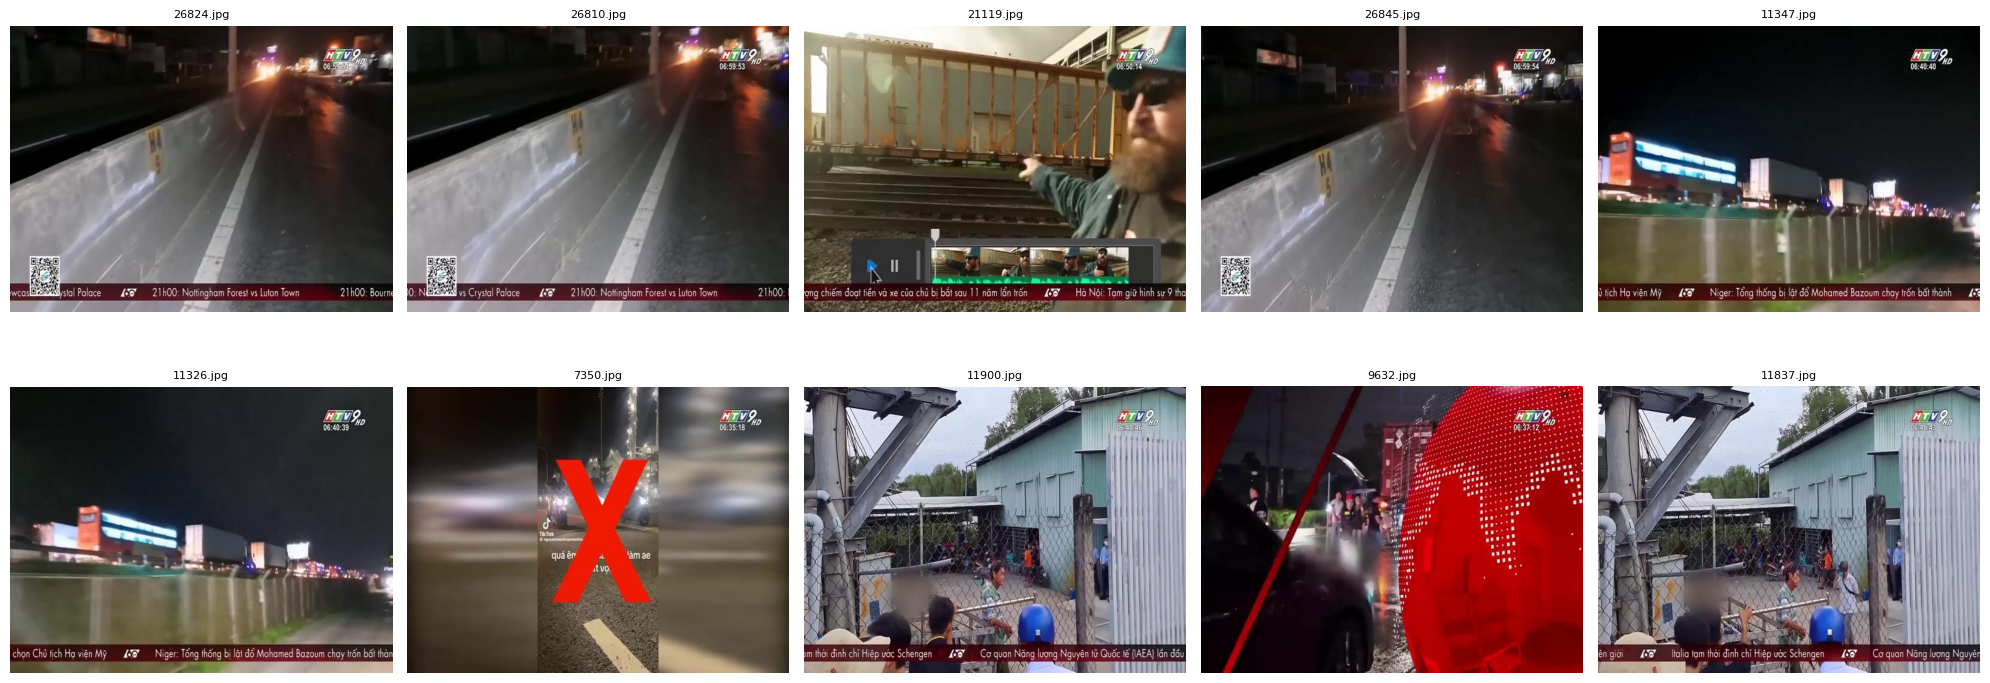

In [10]:
import matplotlib.pyplot as plt
from PIL import Image
import os

# Đường dẫn gốc
base_path = '/kaggle/input/aic-2024-keyframes/aic-2024-keyframes'

# Lấy tất cả đường dẫn ảnh từ result
image_paths = [os.path.join(base_path, img_path) for group in results for (img_path, _) in group]

# Tạo figure hiển thị ảnh
num_images = len(image_paths)
images_per_row = 5
rows = (num_images + images_per_row - 1) // images_per_row  # làm tròn lên

plt.figure(figsize=(20, 4 * rows))

for idx, img_path in enumerate(image_paths):
    try:
        img = Image.open(img_path)
        plt.subplot(rows, images_per_row, idx + 1)
        plt.imshow(img)
        plt.title(os.path.basename(img_path), fontsize=8)
        plt.axis('off')
    except Exception as e:
        print(f"Lỗi khi mở ảnh: {img_path} - {e}")

plt.tight_layout()
plt.show()


In [11]:

vector_models_config = [
    {
        "model_name": "ViT-H-14-378-quickgelu",
        "weight": 1
    }
]
results = faiss_search.search(models_to_search=vector_models_config, queries=['blue car'], k=10)
print(f'results: {results}')

results: [[('L01_V013/19852.jpg', 0.2478712648153305), ('L01_V013/17304.jpg', 0.24720722436904907), ('L01_V020/7329.jpg', 0.2442244291305542), ('L01_V013/19502.jpg', 0.24400681257247925), ('L01_V014/3969.jpg', 0.24174711108207703), ('L01_V013/17332.jpg', 0.24033325910568237), ('L01_V005/22827.jpg', 0.2351161241531372), ('L01_V014/3955.jpg', 0.23434701561927795), ('L01_V011/10780.jpg', 0.23283317685127258), ('L01_V003/22624.jpg', 0.23211953043937683)]]


In [12]:
search_engine = SearchEngine(vector_engine=faiss_search, ocr_engine=meili_search_service)

✅ Main SearchEngine (Optimized Multi-Model Version) initialized.


In [13]:
# import time
# queries = [
#     {"text": "yellow plane", "ocr": "spirit"},
#     {"text": "man in black shirt wearing blue mask"},
#     {"text": "two black suitcases placed side by side"}
# ]
# fusion_weights = {"text": 0.55, "ocr": 0.2, "image": 0.25}
# vector_models_config = [
#     {
#         "model_name": "ViT-H-14-378-quickgelu",
#         "weight": 0.55
#     },
#     # {
#     #     "model_name": "ViT-H-14-quickgelu",
#     #     "weight": 0.45
#     # },
#     # {
#     #     "model_name": "ViT-gopt-16-SigLIP2-384",
#     #     "weight": 1
#     # }
# ]
# start = time.time()
# results = search_engine.temporal_search(
#     queries=queries,
#     k=10,
#     initial_search_k=500,
#     weights=fusion_weights,
#     vector_models_config=models_config
# )
# print(f"process time: {time.time() - start}")
# print(f"results: {results}")

In [14]:
# import matplotlib.pyplot as plt
# from PIL import Image
# import os

# # Đường dẫn gốc
# base_path = '/kaggle/input/aic-2024-keyframes/aic-2024-keyframes'

# # Lấy tất cả đường dẫn ảnh từ result
# image_paths = [os.path.join(base_path, img_path) for group in results for (img_path, _) in group]

# # Tạo figure hiển thị ảnh
# num_images = len(image_paths)
# images_per_row = 5
# rows = (num_images + images_per_row - 1) // images_per_row  # làm tròn lên

# plt.figure(figsize=(20, 4 * rows))

# for idx, img_path in enumerate(image_paths):
#     try:
#         img = Image.open(img_path)
#         plt.subplot(rows, images_per_row, idx + 1)
#         plt.imshow(img)
#         plt.title(os.path.basename(img_path), fontsize=8)
#         plt.axis('off')
#     except Exception as e:
#         print(f"Lỗi khi mở ảnh: {img_path} - {e}")

# plt.tight_layout()
# plt.show()


# 8. ngrok

In [15]:
import os
import uvicorn
from fastapi import FastAPI, File, UploadFile, Form, HTTPException
from fastapi.responses import JSONResponse
from pyngrok import ngrok
from kaggle_secrets import UserSecretsClient
import nest_asyncio
from PIL import Image
import io
import time
user_secrets = UserSecretsClient()
try:
    ngrok_token = user_secrets.get_secret("NGROK_AUTHTOKEN")
    ngrok.set_auth_token(ngrok_token)
    print("Ngrok Authtoken đã được cấu hình!")
except:
    print("LỖI: Không tìm thấy NGROK_AUTHTOKEN trong Kaggle Secrets.")
    print("Vui lòng vào Add-ons -> Secrets để thêm token của bạn.")

app = FastAPI()

Ngrok Authtoken đã được cấu hình!                                                                   


In [16]:
import io
import json
import time
import traceback
from typing import List, Optional, Any
from PIL import Image
from fastapi import FastAPI, File, Form, UploadFile, HTTPException, Request

@app.post("/search")
async def handle_search(
    request: Request,

    k: int = Form(10, description="Số lượng chuỗi video kết quả cuối cùng cần trả về."),

    queries_structure: str = Form(
        ..., 
        description='Một chuỗi JSON mô tả các stage. Ví dụ: \'[{"text": "a plane"}, {"ocr": "spirit"}]\' '
    ),

    image_files: Optional[List[UploadFile]] = Form(
        [],
        description="Một danh sách chứa tất cả các file ảnh được tham chiếu trong 'queries_structure'."
    ),

    weights: Optional[str] = Form(
        None, 
        description='(Optional) Một chuỗi JSON chứa trọng số giữa các loại truy vấn. Ví dụ: \'{"text": 0.5, "ocr": 0.3, "image": 0.2}\''
    ),
    
    vector_models_config: Optional[str] = Form(
        None,
        description='(Optional) Một chuỗi JSON cấu hình các model vector và trọng số. Ví dụ: \'[{"model_name": "clip-vit-h", "weight": 0.7}, {"model_name": "clip-vit-l", "weight": 0.3}]\' '
    )
):
    """
    Thực hiện Temporal Search với cấu hình đa mô hình và trọng số tùy chỉnh.
    """

    try:
        # --- 1. Phân tích các tham số đầu vào (dưới dạng chuỗi JSON) ---
        try:
            parsed_structure = json.loads(queries_structure)
            if not isinstance(parsed_structure, list):
                raise ValueError("queries_structure phải là một mảng JSON.")
        except (json.JSONDecodeError, ValueError) as e:
            raise HTTPException(status_code=400, detail=f"Lỗi phân tích 'queries_structure': {e}")

        parsed_weights = None
        if weights:
            try:
                parsed_weights = json.loads(weights)
                if not isinstance(parsed_weights, dict):
                    raise ValueError("weights phải là một JSON object.")
            except (json.JSONDecodeError, ValueError) as e:
                raise HTTPException(status_code=400, detail=f"Lỗi phân tích 'weights': {e}")
        
        # --- THÊM LOGIC PHÂN TÍCH CHO vector_models_config ---
        parsed_vector_models = None
        if vector_models_config:
            try:
                parsed_vector_models = json.loads(vector_models_config)
                if not isinstance(parsed_vector_models, list):
                    raise ValueError("vector_models_config phải là một mảng JSON.")
                # (Tùy chọn) Thêm kiểm tra sâu hơn cho từng phần tử trong mảng nếu cần
            except (json.JSONDecodeError, ValueError) as e:
                 raise HTTPException(status_code=400, detail=f"Lỗi phân tích 'vector_models_config': {e}")


        # --- 2. Xây dựng lại truy vấn với dữ liệu ảnh ---
        uploaded_images = {file.filename: file for file in image_files}
        reconstructed_queries: List[Dict[str, Any]] = []

        def is_valid(value: Any) -> bool:
            return value not in [None, "", "null"]

        for i, stage_data in enumerate(parsed_structure):
            if not isinstance(stage_data, dict):
                raise HTTPException(status_code=400, detail=f"Stage {i} phải là một object.")

            current_stage = {}
            if 'text' in stage_data and is_valid(stage_data['text']):
                current_stage['text'] = stage_data['text']
            if 'ocr' in stage_data and is_valid(stage_data['ocr']):
                current_stage['ocr'] = stage_data['ocr']
            if 'image_ref' in stage_data and is_valid(stage_data['image_ref']):
                image_filename = stage_data['image_ref']
                if image_filename not in uploaded_images:
                    raise HTTPException(status_code=400, detail=f"Ảnh '{image_filename}' được tham chiếu nhưng không có trong 'image_files'.")
                
                image_file = uploaded_images[image_filename]
                image_data = await image_file.read()
                pil_image = Image.open(io.BytesIO(image_data)).convert('RGB')
                current_stage['image'] = pil_image

            if not current_stage:
                raise HTTPException(status_code=400, detail=f"Stage {i} không chứa truy vấn hợp lệ (text, ocr, hoặc image_ref).")

            reconstructed_queries.append(current_stage)

        # --- 3. Gọi hàm tìm kiếm với đầy đủ các tham số đã được phân tích ---
        start_time = time.time()
        results = search_engine.temporal_search(
            queries=reconstructed_queries, 
            k=k,
            weights=parsed_weights,
            # Truyền cấu hình đa mô hình vào đây
            vector_models_config=parsed_vector_models 
        )
        processing_time = time.time() - start_time
        
        # --- 4. Trả kết quả ---
        return {
            "status": "success",
            "processing_time_seconds": round(processing_time, 3),
            "k_requested": k,
            "results_found": len(results),
            "query_details": {
                 "stages_processed": len(reconstructed_queries),
                 "fusion_weights_used": parsed_weights,
                 "vector_models_used": parsed_vector_models
            },
            "results": results,
        }

    except HTTPException as http_exc:
        # Ghi log lỗi và re-raise để FastAPI xử lý
        print(f"❌ API Error: {http_exc.status_code}, Detail: {http_exc.detail}")
        raise http_exc

    except Exception as e:
        # Ghi log lỗi hệ thống để debug
        print(f"❌ Unhandled System Error: {e}")
        traceback.print_exc()
        raise HTTPException(status_code=500, detail=f"Lỗi hệ thống không mong muốn: {str(e)}")

In [ ]:
nest_asyncio.apply()

public_url = ngrok.connect(8000)
print(f"Public url: {public_url}")

uvicorn.run(app, host="0.0.0.0", port=8000)

INFO:     Started server process [36]
INFO:     Waiting for application startup.
INFO:     Application startup complete.
INFO:     Uvicorn running on http://0.0.0.0:8000 (Press CTRL+C to quit)


Public url: NgrokTunnel: "https://6cd7ae4e6a21.ngrok-free.app" -> "http://localhost:8000"
